In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import truncnorm, norm
import matplotlib.pyplot as plt

In [ ]:
# --- PARAMETERS ---
np.random.seed(42)

# Load gene effect sizes from CSV
# CSV must have two columns: 'gene', 'effect_size'
effect_df = pd.read_csv("effect_sizes.csv")  # <-- your file here
effect_sizes = dict(zip(effect_df['gene'], effect_df['effect_size']))
genes = list(effect_sizes.keys())

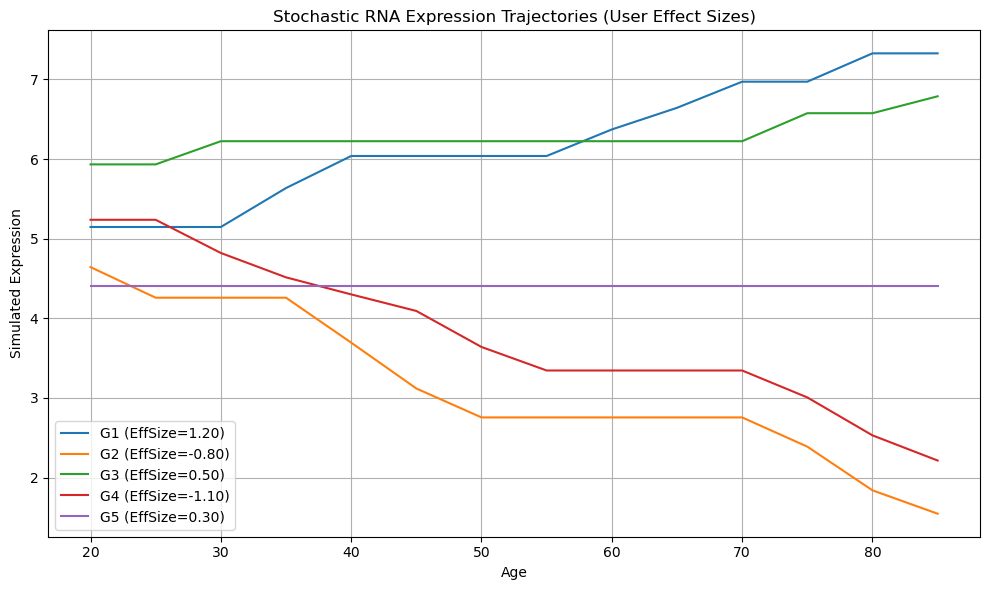

In [2]:
# --- USER INPUT ---
# Dictionary of user-provided effect sizes
effect_sizes = {
    'G1': 1.2,
    'G2': -0.8,
    'G3': 0.5,
    'G4': -1.1,
    'G5': 0.3
}


ages = np.arange(20, 90, 5)
gamma = 0.5     # Global change probability scaling
sigma = 0.2     # Magnitude of stochastic change

genes = list(effect_sizes.keys())

# Optional: Starting expression levels per gene (if known)
starting_expr = {gene: np.random.normal(5, 0.5) for gene in genes}

# --- SIMULATION FUNCTION ---
def simulate_stochastic_expr(ages, genes, effect_sizes, starting_expr, gamma=0.5, sigma=0.2):
    sim_expr = pd.DataFrame(index=ages, columns=genes)
    sim_expr.iloc[0] = [starting_expr[gene] for gene in genes]

    for i in range(1, len(ages)):
        for gene in genes:
            prev = sim_expr.iloc[i - 1][gene]
            eff = effect_sizes[gene]
            prob_change = gamma * abs(eff)

            if np.random.rand() < prob_change:
                if eff > 0:
                    delta = truncnorm.rvs(a=0, b=2, loc=sigma, scale=sigma)
                else:
                    delta = truncnorm.rvs(a=-2, b=0, loc=-sigma, scale=sigma)
                sim_expr.iloc[i][gene] = prev + delta
            else:
                sim_expr.iloc[i][gene] = prev  # no change

    return sim_expr

# --- RUN SIMULATION ---

## This simulation is for fixed gamma and sigma
#sim_expr = simulate_stochastic_expr(ages, genes, effect_sizes, starting_expr, gamma, sigma)

gamma_grid = np.linspace(0.1, 1.0, 10)
sigma_grid = np.linspace(0.05, 0.5, 10)
n_simulations = 50

best_mae = np.inf
best_params = (None, None)

for gamma in gamma_grid:
    for sigma in sigma_grid:
        all_final_expr = []
        for _ in range(n_simulations):
            sim_expr = simulate_stochastic_expr(
                ages=ages, genes=genes,
                effect_sizes=effect_sizes,
                starting_expr=starting_expr,
                gamma=gamma,
                sigma=sigma
            )
            final_expr = sim_expr.iloc[-1]
            all_final_expr.append(final_expr)

        mean_final_expr = pd.DataFrame(all_final_expr).mean()
        mae = np.mean(np.abs(mean_final_expr - observed_old_expr))

        if mae < best_mae:
            best_mae = mae
            best_params = (gamma, sigma)

# --- PLOT ---
def plot_expr(sim_expr, effect_sizes):
    plt.figure(figsize=(10, 6))
    for gene in sim_expr.columns:
        plt.plot(sim_expr.index, sim_expr[gene], label=f"{gene} (EffSize={effect_sizes[gene]:.2f})")
    plt.xlabel("Age")
    plt.ylabel("Simulated Expression")
    plt.title("Stochastic RNA Expression Trajectories (User Effect Sizes)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_expr(sim_expr, effect_sizes)

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import truncnorm
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

np.random.seed(42)

# --------------------------
# PARAMETERS
# --------------------------
n_genes = 353
n_young_samples = 43
ages = np.arange(45, 84)  # 45 to 83 inclusive
samples_per_age = 5
total_samples = len(ages) * samples_per_age

time_steps_per_year = 35
years_diff = 83 - 45
total_time_steps = time_steps_per_year * years_diff  # ~1295 steps

# Global gamma and sigma (can be vectors per gene if you want)
gamma_global = 0.5
sigma_global = 0.02

# Elastic net parameters
alphas = np.linspace(0.001, 1.0, 1001)
l1_ratio = 0.5  # Elastic Net mixing parameter (alpha)

# --------------------------
# STEP 1: Generate synthetic initial RNA expression profiles for youngest samples
# Expression levels roughly normally distributed, gene-specific mean + noise
def simulate_initial_expression(n_samples, n_genes):
    gene_means = np.linspace(5, 10, n_genes)  # example means across genes
    expression = np.random.normal(loc=gene_means, scale=1.0, size=(n_samples, n_genes))
    # Ensure no negative expression values (e.g., TPM or counts)
    expression = np.clip(expression, a_min=0, a_max=None)
    return expression

young_expression = simulate_initial_expression(n_young_samples, n_genes)

# --------------------------
# STEP 2: Simulate stochastic RNA expression trajectories for one sample from initial profile
def simulate_trajectory(initial_profile, gamma, sigma, time_steps):
    profile = initial_profile.copy()
    for _ in range(time_steps):
        for gene_i in range(len(profile)):
            # Probability of change
            p_change = gamma

            if np.random.rand() < p_change:
                # Directionality assumed positive aging change (for simplicity)
                delta = truncnorm.rvs(a=0, b=2, loc=sigma, scale=sigma)
                profile[gene_i] = max(0, profile[gene_i] + delta)  # expression cannot be negative
    return profile

# --------------------------
# STEP 3: Generate cohort by simulating multiple samples across ages
def generate_cohort(young_profiles, ages, samples_per_age, gamma, sigma, time_steps_per_year):
    cohort_data = []
    cohort_ages = []
    n_young = young_profiles.shape[0]
    years_diff = ages[-1] - ages[0]

    for age in ages:
        years_passed = age - ages[0]
        steps = int(years_passed * time_steps_per_year)

        for _ in range(samples_per_age):
            # Sample a random initial young profile
            init_idx = np.random.choice(n_young)
            init_profile = young_profiles[init_idx]

            # Simulate aging trajectory to current age
            simulated_profile = simulate_trajectory(init_profile, gamma, sigma, steps)
            cohort_data.append(simulated_profile)
            cohort_ages.append(age)

    cohort_df = pd.DataFrame(cohort_data, columns=[f"Gene_{i+1}" for i in range(n_genes)])
    cohort_df['Age'] = cohort_ages
    return cohort_df

# Generate three cohorts (train, validation, test)
train_df = generate_cohort(young_expression, ages, samples_per_age, gamma_global, sigma_global, time_steps_per_year)
valid_df = generate_cohort(young_expression, ages, samples_per_age, gamma_global, sigma_global, time_steps_per_year)
test_df  = generate_cohort(young_expression, ages, samples_per_age, gamma_global, sigma_global, time_steps_per_year)

# --------------------------
# STEP 4: Prepare data for elastic net
def prepare_data(df):
    X = df.drop(columns=['Age']).values
    y = df['Age'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # standardize gene expression values per cohort
    return X_scaled, y, scaler

X_train, y_train, scaler_train = prepare_data(train_df)
X_valid, y_valid, scaler_valid = prepare_data(valid_df)
X_test, y_test, scaler_test = prepare_data(test_df)

# --------------------------
# STEP 5: Elastic Net with cross-validation on training set and model selection on validation set

print("Fitting Elastic Net models on training set with CV...")

enet_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratio, cv=5, max_iter=10000, n_jobs=-1)
enet_cv.fit(X_train, y_train)

print(f"Best alpha found by CV on training set: {enet_cv.alpha_:.4f}")

# --------------------------
# STEP 6: Evaluate models along alphas on validation set to pick best alpha

print("Evaluating models on validation set to pick best alpha...")

best_mae = np.inf
best_alpha = None
best_model = None

for alpha in alphas:
    model = ElasticNetCV(alphas=[alpha], l1_ratio=l1_ratio, cv=5, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    mae = mean_absolute_error(y_valid, y_pred)

    if mae < best_mae:
        best_mae = mae
        best_alpha = alpha
        best_model = model

print(f"Selected alpha by validation MAE: {best_alpha:.4f}, MAE: {best_mae:.4f}")

# --------------------------
# STEP 7: Final evaluation on test set

y_test_pred = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test set MAE: {test_mae:.4f}")
print(f"Test set R^2: {test_r2:.4f}")

# --------------------------
# STEP 8: Plot predicted vs observed age on test set

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Elastic Net Predicted Age vs True Age (Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 